In [1]:
import numpy as np
import random
import time

# -------------------------------
# |(0,0)|(0,1)|(0,2)|(0,3)|(0,4)|
# |(1,0)|(1,1)|(1,2)|(1,3)|(1,4)|
# |(2,0)|(2,1)|(2,2)|(2,3)|(2,4)|
# |(3,0)|(3,1)|(3,2)|(3,3)|(3,4)|
# |(4,0)|(4,1)|(4,2)|(4,3)|(4,4)|
# -------------------------------


class GridWorld():
    def __init__(
            self,
            height=5, width=5,        # 격자판의 크기
            start_state=(0, 0),       # 시작 상태
            terminal_states=[(4, 4)], # 종료 상태
            transition_reward=0.0,    # 일반적인 상태 전이 보상
            terminal_reward=1.0,      # 종료 상태로 이동하는 행동 수행
                                      # 때 받는 보상
            outward_reward=0.0,       # 미로 바깥으로 이동하는 행동 수행
                                      # 때 받는 보상
            warm_hole_states=None     # 윔홀 정의
    ):
        self.__version__ = "0.0.1"

        # 그리드월드의 세로 길이
        self.HEIGHT = height

        # 그리드월드의 가로 길이
        self.WIDTH = width

        self.STATES = []
        self.num_states = self.WIDTH * self.HEIGHT

        for i in range(self.HEIGHT):
            for j in range(self.WIDTH):
                self.STATES.append((i, j))

        # 터미널 상태를 상태 집합에서 제거
        for state in terminal_states:
            self.STATES.remove(state)

        self.current_state = None

        # 모든 가능한 행동
        self.ACTION_UP = 0
        self.ACTION_DOWN = 1
        self.ACTION_LEFT = 2
        self.ACTION_RIGHT = 3

        self.ACTIONS = [
            self.ACTION_UP,
            self.ACTION_DOWN,
            self.ACTION_LEFT,
            self.ACTION_RIGHT
        ]

        # UP, DOWN, LEFT, RIGHT
        self.ACTION_SYMBOLS = ["↑", "↓", "←", "→"]

        self.NUM_ACTIONS = len(self.ACTIONS)

        # 시작 상태 위치
        self.START_STATE = start_state

        # 종료 상태 위치
        self.TERMINAL_STATES = terminal_states

        # 웜홀 상태 위치
        self.WARM_HOLE_STATES = warm_hole_states

        # 일반 상태 전이 수행에 대한 보상 값
        self.transition_reward = transition_reward

        # 종료 상태 전이 수행에 대한 보상 값
        self.terminal_reward = terminal_reward

        # 그리드월드 바깥으로 상태 전이 수행해 대한 보상 값
        self.outward_reward = outward_reward


    # 환경 초기화 작업: 에이전트의 현재 위치를 START_STATE로 설정
    def reset(self):
        self.current_state = self.START_STATE
        return self.current_state

    # 에이전트의 현재 위치를 state로 설정
    def moveto(self, state):
        self.current_state = state

    # 주어진 state 상태가 웜홀 상태이면 True 반환하고, 아니면 False 반환
    def is_warm_hole_state(self, state):
        i, j = state

        if self.WARM_HOLE_STATES is not None \
            and len(self.WARM_HOLE_STATES) > 0:
            for warm_hole_info in self.WARM_HOLE_STATES:
                warm_hole_state = warm_hole_info[0]
                if i == warm_hole_state[0] and j == warm_hole_state[1]:
                    return True
        return False

    # 주어진 웜홀 상태 state에 대하여 미리 정해져 있는 다음 상태 반환
    def get_next_state_warm_hole(self, state):
        i, j = state
        next_state = None

        for warm_hole_info in self.WARM_HOLE_STATES:
            warm_hole_state = warm_hole_info[0]
            warm_hole_prime_state = warm_hole_info[1]

            if i == warm_hole_state[0] and j == warm_hole_state[1]:
                next_state = warm_hole_prime_state
                break
        return next_state

    # 주어진 웜홀 상태 state에 대하여 미리 정해져 있는 보상 반환
    def get_reward_warm_hole(self, state):
        i, j = state
        reward = None

        for warm_hole_info in self.WARM_HOLE_STATES:
            warm_hole_state = warm_hole_info[0]
            warm_hole_reward = warm_hole_info[2]

            if i == warm_hole_state[0] and j == warm_hole_state[1]:
                reward = warm_hole_reward
                break

        return reward

    # 주어진 상태 state와 행동 action에 대한 다음 상태 반환
    def get_next_state(self, state, action):
        i, j = state

        # 주어진 상태가 웜홀 상태이면 미리 정해진 다음 상태를 반환
        if self.is_warm_hole_state(state):
            next_state = self.get_next_state_warm_hole(state)
            next_i = next_state[0]
            next_j = next_state[1]
        # 주어진 상태가 종료 상태이면 현재 상태를
        # 다음 상태로 설정하여 반환
        elif (i, j) in self.TERMINAL_STATES:
            next_i = i
            next_j = j
        # 주어진 행동 수행에 따른 다음 상태 반환
        # 주어진 행동에 의하여 그리드월드 밖으로 이동하는 경우
        # 제자리에 멈춤
        else:
            if action == self.ACTION_UP:
                next_i = max(i - 1, 0)
                next_j = j
            elif action == self.ACTION_DOWN:
                next_i = min(i + 1, self.HEIGHT - 1)
                next_j = j
            elif action == self.ACTION_LEFT:
                next_i = i
                next_j = max(j - 1, 0)
            elif action == self.ACTION_RIGHT:
                next_i = i
                next_j = min(j + 1, self.WIDTH - 1)
            else:
                raise ValueError()

        return next_i, next_j

    # 주어진 상태 state에서 다음 상태 next_state로 이동할 경우
    # 얻는 보상 반환
    def get_reward(self, state, next_state):
        i, j = state
        next_i, next_j = next_state

        # 주어진 상태가 웜홀 상태이면 미리 정해진 보상 반환
        if self.is_warm_hole_state(state):
            reward = self.get_reward_warm_hole(state)
        else:
            # 다음 상태가 종료 상태이면 미리 정해진 보상 반환
            if (next_i, next_j) in self.TERMINAL_STATES:
                reward = self.terminal_reward
            else:
                # 주어진 행동에 의하여 그리드월드 밖으로 이동하는 경우
                # 제자리에 멈추면서 미리 정해진 보상 반환
                if i == next_i and j == next_j:
                    reward = self.outward_reward
                # 일반적인 상태 전이인 경우 미리 정해진
                # 일반 전이 보상 반환
                else:
                    reward = self.transition_reward

        return reward

    # 주어진 상태 state에서 행동 action을 수행할 때 전이되는
    # 다음 상태 및 보상과 이에 대한 전이 확률을 반환
    def get_state_action_probability(self, state, action):
        next_i, next_j = self.get_next_state(state, action)

        reward = self.get_reward(state, (next_i, next_j))
        transition_prob = 1.0

        return (next_i, next_j), reward, transition_prob

    # 에이전트가 행동 action을 선택하여 환경에 적용할 때 호출하는 함수
    # 행동 action이 수행된 이후 전이된 다음 상태, 보상, 종료 유무 반환
    def step(self, action):
        next_i, next_j = self.get_next_state(
            state=self.current_state, action=action
        )

        reward = self.get_reward(self.current_state, (next_i, next_j))

        self.current_state = (next_i, next_j)

        if self.current_state in self.TERMINAL_STATES:
            done = True
        else:
            done = False

        return (next_i, next_j), reward, done, None

    # 그리드월드 환경을 화면에 출력
    def render(self, mode='human'):
        print(self.__str__())

    # 임의의 행동을 선택하여 반환
    def get_random_action(self):
        return random.choice(self.ACTIONS)

    # 그리드월드 환경을 문자열로 변환
    def __str__(self):
        gridworld_str = ""
        for i in range(self.HEIGHT):
            gridworld_str += "-------------------------------\n"

            for j in range(self.WIDTH):
                if self.current_state[0] == i and self.current_state[1] == j:
                    gridworld_str += "|  {0}  ".format("*")
                elif (i, j) == self.START_STATE:
                    gridworld_str += "|  {0}  ".format("S")
                elif (i, j) in self.TERMINAL_STATES:
                    gridworld_str += "|  {0}  ".format("G")
                elif self.WARM_HOLE_STATES and \
                     (i, j) in [state[0] for state in self.WARM_HOLE_STATES]:
                    gridworld_str += "|  {0}  ".format("W")
                else:
                    gridworld_str += "|     "
            gridworld_str += "|\n"

            for j in range(self.WIDTH):
                gridworld_str += "|({0},{1})".format(i, j)

            gridworld_str += "|\n"

        gridworld_str += "-------------------------------\n"
        return gridworld_str

import matplotlib.pyplot as plt
from matplotlib.table import Table

# 학습 이후의 가치함수를 표 형태로 그리는 함수
def draw_grid_world_state_values_image(state_values, GRID_HEIGHT, GRID_WIDTH):

    # 축 표시 제거, 크기 조절 등 이미지 그리기를 위한 설정
    fig, ax = plt.subplots()
    ax.set_axis_off()
    table = Table(ax, bbox=[0, 0, 1, 1])

    nrows, ncols = GRID_HEIGHT, GRID_WIDTH
    width, height = 1.0 / ncols, 1.0 / nrows

    # 렌더링 할 이미지에 표 셀과 해당 값 추가
    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            table.add_cell(
                i, j, width, height,
                text=np.round(state_values[i][j], decimals=2),
                loc='center', facecolor='white'
            )

    # 행, 열 라벨 추가
    for i in range(len(state_values)):
        table.add_cell(
            i, -1, width, height,
            text=i+1, loc='right', edgecolor='none', facecolor='none'
        )
        table.add_cell(
            -1, i, width, height/2,
            text=i+1, loc='center', edgecolor='none', facecolor='none'
        )

    for key, cell in table.get_celld().items():
         cell.get_text().set_fontsize(20)

    ax.add_table(table)

    plt.show()
    plt.close()

# 학습 이후의 행동가치함수를 표 형태로 그리는 함수
def draw_grid_world_action_values_image(
    action_values, GRID_HEIGHT, GRID_WIDTH, NUM_ACTIONS, ACTION_SYMBOLS):

    action_str_values = []
    for i in range(GRID_HEIGHT):
        action_str_values.append([])
        for j in range(GRID_WIDTH):
            str_values = []
            for action in range(NUM_ACTIONS):
                str_values.append("{0} ({1}): {2:.2f}".format(
                    ACTION_SYMBOLS[action],
                    action,
                    np.round(action_values[i, j, action], decimals=2)
                ))
            action_str_values[i].append("\n".join(str_values))

    # 축 표시 제거, 크기 조절 등 이미지 그리기 이전 설정 작업
    fig, ax = plt.subplots()
    ax.set_axis_off()
    table = Table(ax, bbox=[0, 0, 1, 1])

    nrows, ncols = GRID_HEIGHT, GRID_WIDTH
    width, height = 1.0 / ncols, 1.0 / nrows

    # 렌더링 할 이미지에 표 셀과 해당 값 추가
    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            table.add_cell(
                i, j, width, height,
                text=action_str_values[i][j],
                loc='center', facecolor='white'
            )

    # 행, 열 라벨 추가
    for i in range(len(action_str_values)):
        table.add_cell(
            i, -1, width, height,
            text=i+1, loc='right', edgecolor='none', facecolor='none')
        table.add_cell(
            -1, i, width, height/2,
            text=i+1, loc='center', edgecolor='none', facecolor='none')

    for key, cell in table.get_celld().items():
         cell.get_text().set_fontsize(10)

    ax.add_table(table)

    plt.show()
    plt.close()

# 학습 이후의 최적 정책을 표 형태로 그리는 함수
def draw_grid_world_optimal_policy_image(
    policy, GRID_HEIGHT, GRID_WIDTH, ACTION_SYMBOLS, TERMINAL_STATES=None):

    action_str_values = []
    for i in range(GRID_HEIGHT):
        action_str_values.append([])
        for j in range(GRID_WIDTH):
            if TERMINAL_STATES and (i, j) in TERMINAL_STATES:
                continue
            str_values = []
            actions, probs = policy[(i, j)]
            for action in actions:
                str_values.append("{0} ({1})".format(
                    ACTION_SYMBOLS[action],
                    np.round(probs[action], decimals=3)
                ))
            action_str_values[i].append("\n".join(str_values))

    # 축 표시 제거, 크기 조절 등 이미지 그리기 이전 설정 작업
    fig, ax = plt.subplots()
    ax.set_axis_off()
    table = Table(ax, bbox=[0, 0, 1, 1])

    nrows, ncols = GRID_HEIGHT, GRID_WIDTH
    width, height = 1.0 / ncols, 1.0 / nrows

    # 렌더링 할 이미지에 표 셀과 해당 값 추가
    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            if TERMINAL_STATES and (i, j) in TERMINAL_STATES:
                continue
            table.add_cell(i, j, width, height, text=action_str_values[i][j],
                           loc='center', facecolor='white')

    # 행, 열 라벨 추가
    for i in range(len(action_str_values)):
        table.add_cell(i, -1, width, height, text=i+1, loc='right',
                       edgecolor='none', facecolor='none')
        table.add_cell(-1, i, width, height/2, text=i+1, loc='center',
                       edgecolor='none', facecolor='none')

    for key, cell in table.get_celld().items():
         cell.get_text().set_fontsize(10)

    ax.add_table(table)

    plt.show()
    plt.close()

def softmax(x):
    B = np.exp(x - np.max(x))
    C = np.sum(B)
    return B/C

Iteration: 0
Iteration: 1000
Iteration: 2000
Iteration: 3000
Iteration: 4000
Iteration: 5000
Iteration: 6000
Iteration: 7000
Iteration: 8000
Iteration: 9000
Iteration: 9999


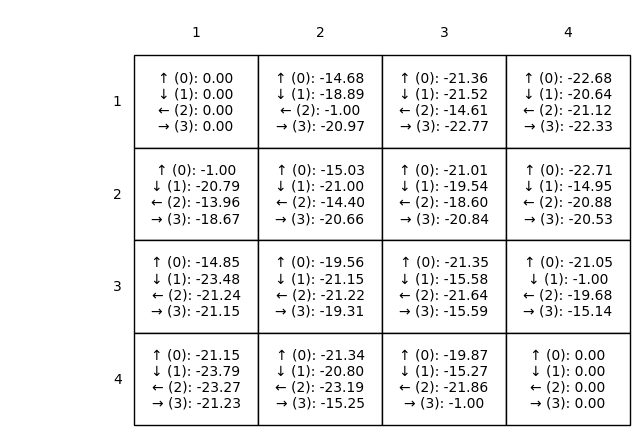

Iteration: 0
Iteration: 1000
Iteration: 2000
Iteration: 3000
Iteration: 4000
Iteration: 5000
Iteration: 6000
Iteration: 7000
Iteration: 8000
Iteration: 9000
Iteration: 9999


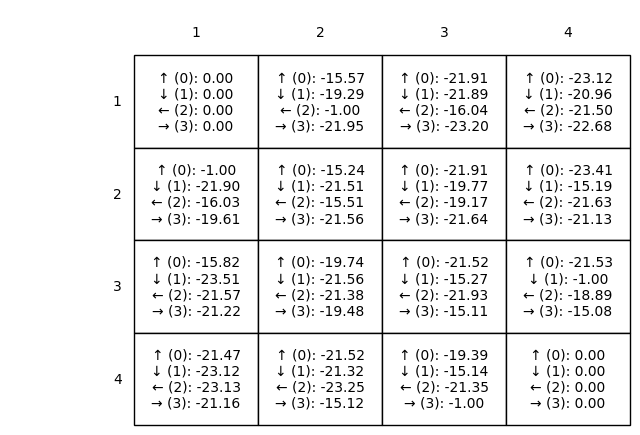

In [2]:
GRID_HEIGHT = 4
GRID_WIDTH = 4
TERMINAL_STATES = [(0, 0), (GRID_HEIGHT-1, GRID_WIDTH-1)]

def get_exploring_start_state():
    while True:
        i = random.randrange(GRID_HEIGHT)
        j = random.randrange(GRID_WIDTH)
        if (i, j) not in TERMINAL_STATES:
            break
    return (i, j)

# 환경에서 무작위로 에피소드 생성
def generate_random_episode_and_state_actions(env):
    episode = []
    visited_state_actions = []

    # 탐험적 시작 기반 몬테카를로 제어
    initial_state = get_exploring_start_state()
    env.moveto(initial_state)

    state = initial_state
    done = False
    while not done:
        # 상태에 관계없이 항상 4가지 행동 중 하나를 선택하여 수행
        action = random.randrange(env.NUM_ACTIONS)

        next_state, reward, done, _ = env.step(action)

        episode.append(((state, action), reward))
        visited_state_actions.append((state, action))

        state = next_state

    return episode, visited_state_actions

# 첫 방문 행동 가치 MC 예측
def first_visit_mc_prediction(env, gamma, num_iter):
    # 비어있는 상태-가치 함수를 0으로 초기화하며 생성함
    state_action_values = np.zeros((GRID_HEIGHT, GRID_WIDTH, env.NUM_ACTIONS))
    returns = dict()
    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            for action in env.ACTIONS:
                returns[((i, j), action)] = list()

    for i in range(num_iter):
        episode, visited_state_actions = generate_random_episode_and_state_actions(env)

        G = 0
        for idx, ((state, action), reward) in enumerate(reversed(episode)):
            G = gamma * G + reward

            value_prediction_conditions = [
                (state, action) not in \
                    visited_state_actions[:len(visited_state_actions) - idx - 1],
                state not in TERMINAL_STATES
            ]

            if all(value_prediction_conditions):
                returns[(state, action)].append(G)
                state_action_values[state[0], state[1], action] \
                    = np.mean(returns[(state, action)])
    
        if i % 1000 == 0:
            print("Iteration: {0}".format(i))

    print("Iteration: {0}".format(i))
    
    return state_action_values, returns

# 모든 방문 행동 가치 MC 예측
def every_visit_mc_prediction(env, gamma, num_iter):
    # 비어있는 상태-가치 함수를 0으로 초기화하며 생성함
    state_action_values = np.zeros((GRID_HEIGHT, GRID_WIDTH, env.NUM_ACTIONS))
    returns = dict()
    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            for action in env.ACTIONS:
                returns[((i, j), action)] = list()

    for i in range(num_iter):
        episode, _ = generate_random_episode_and_state_actions(env)

        G = 0
        for idx, ((state, action), reward) in enumerate(reversed(episode)):
            G = gamma * G + reward

            value_prediction_conditions = [
                state not in TERMINAL_STATES
            ]

            if all(value_prediction_conditions):
                returns[(state, action)].append(G)
                state_action_values[state[0], state[1], action] \
                    = np.mean(returns[(state, action)])

        if i % 1000 == 0:
            print("Iteration: {0}".format(i))

    print("Iteration: {0}".format(i))

    return state_action_values, returns

def action_value_prediction_main():
    # 그리드 월드 환경 객체 생성
    env = GridWorld(
        height=GRID_HEIGHT,
        width=GRID_WIDTH,
        start_state=None,
        terminal_states=TERMINAL_STATES,
        transition_reward=-1.0,
        terminal_reward=-1.0,
        outward_reward=-1.0
    )
    env.reset()

    state_action_values, returns = first_visit_mc_prediction(env, 1.0, 10000)
    draw_grid_world_action_values_image(
        state_action_values,
        GRID_HEIGHT, GRID_WIDTH,
        env.NUM_ACTIONS,
        env.ACTION_SYMBOLS
    )

    state_action_values, returns = every_visit_mc_prediction(env, 1.0, 10000)
    draw_grid_world_action_values_image(
        state_action_values,
        GRID_HEIGHT, GRID_WIDTH,
        env.NUM_ACTIONS,
        env.ACTION_SYMBOLS
    )

if __name__ == "__main__":
    action_value_prediction_main()

[[[ MC 제어 반복 시작! ]]]
*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 4.0500000], 총 반복 수: 1 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 10.6500000], 총 반복 수: 2 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 3 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 4 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 5 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 6 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 7 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 8 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 9 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 10 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 11 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.00000

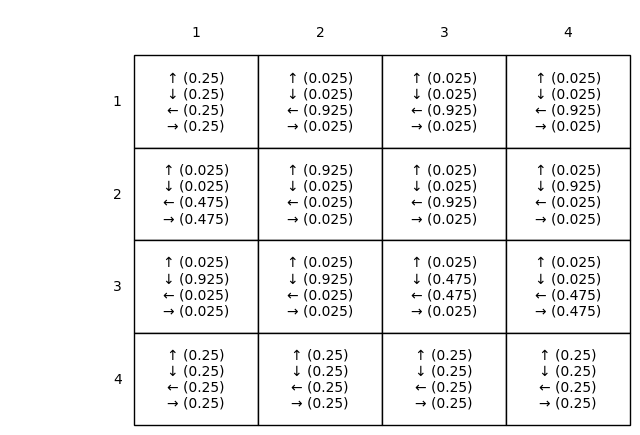

In [3]:
EPSILON = 0.1

GRID_HEIGHT = 4
GRID_WIDTH = 4
TERMINAL_STATES = [(0, 0), (GRID_HEIGHT-1, GRID_WIDTH-1)]
DISCOUNT_RATE = 1.0
MAX_EPISODES = 100

# 비어있는 행동 가치 테이블을 0으로 초기화하며 생성함
def generate_initial_q_value_and_return(env):
    state_action_values = np.zeros((GRID_HEIGHT, GRID_WIDTH, env.NUM_ACTIONS))
    returns = dict()

    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            for action in env.ACTIONS:
                returns[((i, j), action)] = list()

    return state_action_values, returns

# 모든 상태에서 수행 가능한 행동에 맞춰 임의의 정책을 생성함
# 초기에 각 행동의 선택 확률은 모두 같음
def generate_initial_random_policy(env):
    policy = dict()

    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            actions = []
            prob = []
            for action in env.ACTIONS:
                actions.append(action)
                prob.append(0.25)
            policy[(i, j)] = (actions, prob)

    return policy

# 환경에서 현재 정책에 입각하여 에피소드(현재 상태, 행동, 다음 상태, 보상) 생성
def generate_episode(env, policy):
    episode = []
    visited_state_actions = []

    state = env.reset()  # 초기 상태 고정 (0, 1)

    done = False
    while not done:
        actions, prob = policy[state]
        action = np.random.choice(actions, size=1, p=prob)[0]

        next_state, reward, done, _ = env.step(action)

        episode.append(((state, action), reward))
        visited_state_actions.append((state, action))

        state = next_state

    return episode, visited_state_actions

# 첫 방문 행동 가치 MC 추정 함수
def first_visit_mc_prediction(
    state_action_values, returns, episode, visited_state_actions):
    G = 0
    for idx, ((state, action), reward) in enumerate(reversed(episode)):
        G = DISCOUNT_RATE * G + reward

        value_prediction_conditions = [
            (state, action) not in \
                visited_state_actions[:len(visited_state_actions) - idx - 1],
            state not in TERMINAL_STATES
        ]

        if all(value_prediction_conditions):
            returns[(state, action)].append(G)
            state_action_values[state[0], state[1], action] \
                = np.mean(returns[(state, action)])

# 소프트 탐욕적 정책 생성
def generate_soft_greedy_policy(env, state_action_values, policy):
    new_policy = dict()

    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            actions = []
            action_probs = []
            if (i, j) in TERMINAL_STATES:
                for action in env.ACTIONS:
                    actions.append(action)
                    action_probs.append(0.25)
                new_policy[(i, j)] = (actions, action_probs)
            else:
                max_prob_actions = [action_ for action_, value_ 
                                    in enumerate(state_action_values[i, j, :]) if
                                    value_ == np.max(state_action_values[i, j, :])]
                for action in env.ACTIONS:
                    actions.append(action)
                    if action in max_prob_actions:
                        action_probs.append(
                            (1 - EPSILON) / len(max_prob_actions) \
                            + EPSILON / env.NUM_ACTIONS
                        )
                    else:
                        action_probs.append(
                            EPSILON / env.NUM_ACTIONS
                        )

                new_policy[(i, j)] = (actions, action_probs)

    error = 0.0
    for i in range(GRID_HEIGHT):
        for j in range(GRID_WIDTH):
            error += np.sum(
                np.absolute(
                    np.array(policy[(i, j)][1]) - np.array(new_policy[(i, j)][1])
                )
            )

    return new_policy, error

def soft_policy_control_main():
    # 그리드 월드 환경 객체 생성
    env = GridWorld(
        height=GRID_HEIGHT,
        width=GRID_WIDTH,
        start_state=(0, 1),       # 시작 상태 고정
        terminal_states=TERMINAL_STATES,
        transition_reward=-1.0,
        terminal_reward=-1.0,
        outward_reward=-1.0
    )

    # 비어있는 상태-가치 함수를 0으로 초기화하며 생성함
    state_action_values, returns = generate_initial_q_value_and_return(env)

    # 초기 임의 정책 생성
    policy = generate_initial_random_policy(env)

    iter_num = 0

    print("[[[ MC 제어 반복 시작! ]]]")
    while iter_num < MAX_EPISODES:
        iter_num += 1

        episode, visited_state_actions = generate_episode(env, policy)
        print("*** 에피소드 생성 완료 ***")

        first_visit_mc_prediction(
            state_action_values, returns, episode, visited_state_actions
        )
        print("*** MC 예측 수행 완료 ***")

        policy, error = generate_soft_greedy_policy(
            env, state_action_values, policy
        )
        print("*** 정책 개선 [에러 값: {0:9.7f}], 총 반복 수: {1} ***\n".format(
            error, iter_num
        ))

    print("[[[ MC 제어 반복 종료! ]]]\n\n")

    draw_grid_world_optimal_policy_image(
        policy,
        GRID_HEIGHT, GRID_WIDTH,
        env.ACTION_SYMBOLS
    )

if __name__ == "__main__":
    soft_policy_control_main()

In [4]:
import random
import time

# -------------------------------
# T1 0 1 2 3 4 T2
# -------------------------------


class RandomWalk():
    def __init__(
            self,
            num_internal_states=5,        # 종료 상태를 제외한 내부 상태 개수
            transition_reward=0.0,        # 일반적인 상태 전이 보상
            left_terminal_reward=0.0,     # 왼쪽 종료 상태로 이동하는 행동 
                                          # 수행 시 받는 보상
            right_terminal_reward=1.0     # 오른쪽 종료 상태로 이동하는 행동 
                                          # 수행 시 받는 보상
    ):
        self.__version__ = "0.0.1"

        self.num_internal_states = num_internal_states

        self.num_states = num_internal_states + 2
        self.STATES = [i for i in range(num_internal_states)]
        self.TERMINAL_STATES = ['T1', 'T2']

        # 모든 가능한 행동
        self.ACTION_LEFT = 0
        self.ACTION_RIGHT = 1
        self.ACTION_SYMBOLS = ["\u2190", "\u2192"]

        # 종료 상태를 제외한 임의의 상태에서 왼쪽 이동 또는 오른쪽 이동
        self.ACTIONS = [
            self.ACTION_LEFT,
            self.ACTION_RIGHT
        ]
        self.NUM_ACTIONS = len(self.ACTIONS)

        # 시작 상태 위치
        self.START_STATE = self.STATES[int(num_internal_states / 2)]

        self.transition_reward = transition_reward

        self.left_terminal_reward = left_terminal_reward

        self.right_terminal_reward = right_terminal_reward

        self.current_state = None

    def reset(self):
        self.current_state = self.START_STATE
        return self.current_state

    def moveto(self, state):
        self.current_state = state

    def get_next_state(self, state, action):
        if state in self.TERMINAL_STATES:
            next_state = state
        else:
            if action == self.ACTION_LEFT:
                if state == 0:
                    next_state = 'T1'
                else:
                    next_state = state - 1
            elif action == self.ACTION_RIGHT:
                if state == self.num_internal_states - 1:
                    next_state = 'T2'
                else:
                    next_state = state + 1
            else:
                raise ValueError()

        return next_state

    def get_reward(self, state, next_state):
        if next_state == 'T1':
            reward = self.left_terminal_reward
        elif next_state == 'T2':
            reward = self.right_terminal_reward
        else:
            reward = self.transition_reward

        return reward

    def get_state_action_probability(self, state, action):
        next_state = self.get_next_state(state, action)

        reward = self.get_reward(state, next_state)
        prob = 1.0

        return next_state, reward, prob

    # take @action in @state
    # @return: (reward, new state)
    def step(self, action):
        next_state = self.get_next_state(
            state=self.current_state, action=action
        )

        reward = self.get_reward(self.current_state, next_state)

        self.current_state = next_state

        if self.current_state in self.TERMINAL_STATES:
            done = True
        else:
            done = False

        return next_state, reward, done, None

    def render(self, mode='human'):
        print(self.__str__(), end="\n\n")

    def get_random_action(self):
        return random.choice(self.ACTIONS)

    def __str__(self):
        randomwalk_str = ""
        randomwalk_str += " T1 " + " ".join(
            ["{0}".format(i) for i in range(self.num_internal_states)]
        ) + " T2\n"

        if self.current_state in self.STATES:
            blank = "    " + "  " * self.current_state
        elif self.current_state == 'T1':
            blank = " "
        elif self.current_state == 'T2':
            blank = "  " + "  " * (self.num_internal_states + 1)
        else:
            raise ValueError()

        randomwalk_str += blank + "*"

        return randomwalk_str

# 랜덤워크 정책 이미지 산출 함수
def draw_random_walk_policy_image(policy, env):
    randomwalk_str = ""
    randomwalk_str += " T1      " + "       ".join(
        ["{0}".format(i) for i in range(env.num_internal_states)]
    ) + "      T2\n"

    randomwalk_str += "       "
    for state in env.STATES:
        actions, prob = policy[state]
        randomwalk_str += "{0}:{1:4}  ".format(
            env.ACTION_SYMBOLS[env.ACTION_LEFT],
            np.round(prob[env.ACTION_LEFT], decimals=2)
        )
    randomwalk_str += "\n"

    randomwalk_str += "       "
    for state in env.STATES:
        actions, prob = policy[state]
        randomwalk_str += "{0}:{1:4}  ".format(
            env.ACTION_SYMBOLS[env.ACTION_RIGHT],
            np.round(prob[env.ACTION_RIGHT], decimals=2)
        )

    print(randomwalk_str)

In [5]:
DISCOUNT_RATE = 0.9
MAX_EPISODES = 50
EPSILON = 0.1

# 비어있는 행동 가치 테이블을 0으로 초기화하며 생성함
def generate_initial_q_value_and_return(env):
    state_action_values = np.zeros((env.num_internal_states, env.NUM_ACTIONS))
    returns = dict()

    for state in env.STATES:
        for action in env.ACTIONS:
            returns[(state, action)] = list()

    return state_action_values, returns

# 모든 상태에서 수행 가능한 행동에 맞춰 임의의 정책을 생성함
# 초기에 각 행동의 선택 확률은 모두 같음
def generate_initial_random_policy(env):
    policy = dict()

    for state in env.STATES:
        actions = []
        prob = []
        for action in env.ACTIONS:
            actions.append(action)
            prob.append(0.5)
        policy[state] = (actions, prob)

    return policy

# 환경에서 현재 정책에 입각하여 에피소드(현재 상태, 행동, 다음 상태, 보상) 생성
def generate_episode(env, policy):
    episode = []
    visited_state_actions = []

    state = env.reset()  # exploring start

    done = False
    while not done:
        actions, prob = policy[state]
        action = np.random.choice(actions, size=1, p=prob)[0]
        next_state, reward, done, _ = env.step(action)

        episode.append(((state, action), reward))
        visited_state_actions.append((state, action))

        state = next_state

    return episode, visited_state_actions

# 첫 방문 행동 가치 MC 추정 함수
def first_visit_mc_prediction(
    state_action_values, returns, episode, visited_state_actions, env):
    G = 0
    for idx, ((state, action), reward) in enumerate(reversed(episode)):
        G = DISCOUNT_RATE * G + reward

        value_prediction_conditions = [
            (state, action) not in \
                visited_state_actions[:len(visited_state_actions) - idx - 1],
            state not in env.TERMINAL_STATES
        ]

        if all(value_prediction_conditions):
            returns[(state, action)].append(G)
            state_action_values[state, action] = np.mean(returns[(state, action)])

# 소프트 탐욕적 정책 생성
def generate_soft_greedy_policy(env, state_action_values, policy):
    new_policy = dict()

    for state in env.STATES:
        actions = []
        action_probs = []
        if state in env.TERMINAL_STATES:
            for action in range(env.NUM_ACTIONS):
                actions.append(action)
                action_probs.append(0.5)
            new_policy[state] = (actions, action_probs)
        else:
            max_prob_actions = [action_ for action_, value_ 
                                in enumerate(state_action_values[state, :]) if
                                value_ == np.max(state_action_values[state, :])]
            for action in range(env.NUM_ACTIONS):
                actions.append(action)
                if action in max_prob_actions:
                    action_probs.append(
                        (1 - EPSILON) / len(max_prob_actions) \
                        + EPSILON / env.NUM_ACTIONS
                    )
                else:
                    action_probs.append(
                        EPSILON / env.NUM_ACTIONS
                    )

            new_policy[state] = (actions, action_probs)

    error = 0.0
    for i in env.STATES:
        error += np.sum(
            np.absolute(
                np.array(policy[i][1]) - np.array(new_policy[i][1])
            )
        )

    return new_policy, error

def random_walk_soft_policy_control_main():
    # 랜덤 워크 환경 객체 생성
    env = RandomWalk(
        num_internal_states=5,
        transition_reward=0.0,
        left_terminal_reward=0.0,
        right_terminal_reward=1.0
    )

    # 비어있는 상태-가치 함수를 0으로 초기화하며 생성함
    state_action_values, returns = generate_initial_q_value_and_return(env)

    # 초기 임의 정책 생성
    policy = generate_initial_random_policy(env)

    iter_num = 0

    print("[[[ MC 제어 반복 시작! ]]]")
    while iter_num < MAX_EPISODES:
        iter_num += 1

        episode, visited_state_actions = generate_episode(env, policy)
        print("*** 에피소드 생성 완료 ***")

        first_visit_mc_prediction(
            state_action_values, returns, episode, visited_state_actions, env
        )
        print("*** MC 예측 수행 완료 ***")

        policy, error = generate_soft_greedy_policy(
            env, state_action_values, policy
        )
        print("*** 정책 개선 [에러 값: {0:9.7f}], 총 반복 수: {1} ***\n".format(
            error, iter_num
        ))

    print("[[[ MC 제어 반복 종료! ]]]\n\n")

    draw_random_walk_policy_image(policy, env)

if __name__ == "__main__":
    random_walk_soft_policy_control_main()

[[[ MC 제어 반복 시작! ]]]
*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 2.7000000], 총 반복 수: 1 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 2 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 3 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 4 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 5 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 6 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 7 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 8 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 9 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 10 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.0000000], 총 반복 수: 11 ***

*** 에피소드 생성 완료 ***
*** MC 예측 수행 완료 ***
*** 정책 개선 [에러 값: 0.000000